# [CrisisMMD v.2](https://crisisnlp.qcri.org/crisismmd.html)


---

## A. Original description

The CrisisMMD multimodal Twitter dataset consists of several thousands of manually annotated tweets and images collected during seven major natural disasters including earthquakes, hurricanes, wildfires, and floods that happened in the year 2017 across different parts of the World. The provided datasets include three types of annotations.

Change log version 2.0: In this version of this dataset, we mapped "Not relevant or can't judge" to "Not humanitarian" for the humanitarian task. Also the "Not informative" label from informative task also mapped to "Not humanitarian" for the humanitarian task. We also removed duplicate entries that appeared while combined the tweets from different events. Both informative and humanitarian tasks are now aligned and can be useful for multitask classification learning.


#### Data format and files

The directory contains the files for different tasks:

- "task*.tsv" - training, development and test set split for the mentioned tasks.

##### Format of the TSV files under the "annotations" directory
Each TSV file in this directory contains the following columns, separated by a tab:

* event_name: corresponds to the name of the event.
* tweet_id: corresponds to the actual tweet id from Twitter.
* image_id: corresponds to a combination of a "tweet_id" and an index concatenated with an underscore. The integer indices represent different images associated with a given tweet.
* tweet_text: corresponds to the original text of a given tweet as downloaded from Twitter.
* image: corresponds to the relative path of an image inside the "data_image" folder for a given tweet.
* label: for informativeness and humanitarian tasks randomly selected labels from text and image labels; for damage task we only have a label for the image.
* label_text: corresponds to the task-specific label (i.e., informative for informativeness, infrastructure_and_utility_damage for humanitarian) assigned to a given tweet text; for the damage task, we do not provide this column.
* label_image: corresponds to the task-specific label (i.e., informative, infrastructure_and_utility_damage for humanitarian) assigned to a given tweet image; for the damage task, we do not provide this column.
* label_text_image: corresponds to the positive and negative label, which represents whether text and image labels are the same (e.g., positive) or not (e.g., negative).

### Ref
- Ferda Ofli, Firoj Alam, and Muhammad Imran, Analysis of Social Media Data using Multimodal Deep Learning for Disaster Response, In Proceedings of the 17th International Conference on Information Systems for Crisis Response and Management (ISCRAM), 2020, USA.
- Firoj Alam, Ferda Ofli, and Muhammad Imran, CrisisMMD: Multimodal Twitter Datasets from Natural Disasters, In Proceedings of the 12th International AAAI Conference on Web and Social Media (ICWSM), 2018, Stanford, California, USA.

## B. Data Processing

There are two folders
- crisismmd_datasplit_agreed_label
- crisismmd_datasplit_all

We consider only a subset of the original dataset where text and image pairs have the same label for a
given task, therefore, only `crisismmd_datasplit_agreed_label` is used.


** Task 1: Informative vs Not informative
   * Informative
   * Not informative

** Task 2: Humanitarian categories,

only used the data which was labeled as “informative” (i.e., either text or image was informative) in Task 1.
   * Affected individuals
   * Infrastructure and utility damage
   * Rescue, volunteering or donation effort
   * Other relevant information
   * Not humanitarian

In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd

import configuration
from src import dataset_settings

from dotenv import load_dotenv
load_dotenv()

True

### B.1. Data Loading and Structural handling

> Social media data poses great challenges and one of the major change is multimodal data, in which there is no strong alignment between modalities (i.e., same text and image pair have different labels).
>
> For this study and as a preliminary experiments, we only selected the ones with agreed labels. 

In [2]:
dataset_path = Path(os.getenv("DATASETS_PATH")) / 'CrisisMMD' / 'V2'
base_dir = dataset_path / 'crisismmd_datasplit_agreed_label'
allFiles = sorted(base_dir.rglob('*.tsv'))

# Quick check of the files in the dataset
df = pd.read_csv(allFiles[0], sep='\t', encoding='utf_8')
df.head()

,event_name,tweet_id,image_id,tweet_text,image,label,label_text,label_image,label_text_image
0,california_wildfires,920329866901381123,920329866901381123_0,Family Miraculously Finds Dog They Lost When E...,data_image/california_wildfires/17_10_2017/920...,not_humanitarian,not_humanitarian,not_humanitarian,Positive
1,hurricane_irma,909744783115120640,909744783115120640_0,Hurricane Irma on #Twitter https://t.co/HDssyS...,data_image/hurricane_irma/18_9_2017/9097447831...,other_relevant_information,other_relevant_information,other_relevant_information,Positive
2,hurricane_irma,909925247331241984,909925247331241984_0,i feel attacked by jin in so many levels how t...,data_image/hurricane_irma/18_9_2017/9099252473...,not_humanitarian,not_humanitarian,not_humanitarian,Positive
3,hurricane_irma,909819142970241024,909819142970241024_0,"Post-IRMA, I can testify - SO TRUE. https://t....",data_image/hurricane_irma/18_9_2017/9098191429...,not_humanitarian,not_humanitarian,not_humanitarian,Positive
4,hurricane_maria,910526223918309376,910526223918309376_0,Hurricane Maria remains a severe threat 20 Sep...,data_image/hurricane_maria/20_9_2017/910526223...,other_relevant_information,other_relevant_information,other_relevant_information,Positive


#### Concat all files

In [3]:
metadata = {
    'hurricane_maria':{
        "country": "US",
        "event_type": "storm",
    },
    'hurricane_harvey':{
        "country": "US",
        "event_type": "storm",
    },
    'hurricane_irma':{
        "country": "US",
        "event_type": "storm",
    },
    'california_wildfires':{
        "country": "US",
        "event_type": "wildfire",
    },
    'mexico_earthquake':{
        "country": "Mexico",
        "event_type": "earthquake",
    },
    'srilanka_floods':{
        "country": "Sri Lanka",
        "event_type": "flood",
    },
    'iraq_iran_earthquake':{
        "country": "Iraq/Iran",
        "event_type": "earthquake",
    },
}

In [4]:
dfs = []
all_files = sorted(base_dir.rglob('*.tsv'))
for file in all_files:
    parent_name = file.parent.name
    df = pd.read_csv(file, sep='\t', encoding='utf_8')
    df['year'] = 2017
    # df['country'] = df['event_name'].apply(lambda x: metadata[x]['country'])
    df['event_type'] = df['event_name'].apply(lambda x: metadata[x]['event_type'])
    df['dataset'] = 'CrisisMMD_v2'
    df['meta'] = df['event_name'].apply(lambda x: {
        'event_name': x,
        'file_name': file.name,
    })

    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
df.drop(
    columns=['label_text', 'label_image', 'label_text_image', 'image_id', 'image'],
    inplace=True)

In [5]:
df.head()

,event_name,tweet_id,tweet_text,label,year,event_type,dataset,meta
0,california_wildfires,920329866901381123,Family Miraculously Finds Dog They Lost When E...,not_humanitarian,2017,wildfire,CrisisMMD_v2,"{'event_name': 'california_wildfires', 'file_n..."
1,hurricane_irma,909744783115120640,Hurricane Irma on #Twitter https://t.co/HDssyS...,other_relevant_information,2017,storm,CrisisMMD_v2,"{'event_name': 'hurricane_irma', 'file_name': ..."
2,hurricane_irma,909925247331241984,i feel attacked by jin in so many levels how t...,not_humanitarian,2017,storm,CrisisMMD_v2,"{'event_name': 'hurricane_irma', 'file_name': ..."
3,hurricane_irma,909819142970241024,"Post-IRMA, I can testify - SO TRUE. https://t....",not_humanitarian,2017,storm,CrisisMMD_v2,"{'event_name': 'hurricane_irma', 'file_name': ..."
4,hurricane_maria,910526223918309376,Hurricane Maria remains a severe threat 20 Sep...,other_relevant_information,2017,storm,CrisisMMD_v2,"{'event_name': 'hurricane_maria', 'file_name':..."


In [6]:
df.shape

(20787, 8)

### B.2. Cleaning and Mapping
#### B.2.1. Remove duplicated

> #### Original Manual Annotation
> **Task 1: Informative vs. Not informative**
>
> Informative or not informative for all the events.
>
> `Informative`:
> - If the given tweet/image is useful for humanitarian aid
> - if it reports/shows one or more of the following: cautions, advice, and warnings, injured, dead, or affected people, rescue, volunteering, or donation request or effort, damaged houses, damaged roads, damaged buildings; ﬂooded houses, ﬂooded streets; blocked roads, blocked bridges, blocked pathways; any built structure affected by earthquake, ﬁre, heavy rain, strong winds, gust, etc., disaster area maps.
>
> `Not informative` otherwise
> - - -
> “Humanitarian aid” deﬁnition: In response to humanitarian crises including natural and man-made disasters, humanitarian aid involves providing assistance to people who need help.

> **Task 2: Humanitarian Categories**
>
> Only used the data which was labeled as `informative` (i.e., either text or image was informative) in Task 1.
> 

---

**B.2.1.1 `not_humanitarian` and `not_informative` are identical**

=> drop `not_humanitarian`



In [7]:
# check if `not_informative` and `not_humanitarian` tweets have the same `tweet_id`
not_informative_tweet_ids = set(df[df['label'] == 'not_informative']['tweet_id'])
not_humanitarian_tweet_ids = set(df[df['label'] == 'not_humanitarian']['tweet_id'])

print(f"Number of unique tweet_ids in `not_informative`: {len(not_informative_tweet_ids)}")
print(f"Number of unique tweet_ids in `not_humanitarian`: {len(not_humanitarian_tweet_ids)}")

print(f"Are the sets of tweet_ids in `not_informative` and `not_humanitarian` identical? {not_informative_tweet_ids == not_humanitarian_tweet_ids}")

# drop all `not_humanitarian` tweets since they are the same as `not_informative`
df = df[df['label'] != 'not_humanitarian']

Number of unique tweet_ids in `not_informative`: 3768
Number of unique tweet_ids in `not_humanitarian`: 3768
Are the sets of tweet_ids in `not_informative` and `not_humanitarian` identical? True


**B.2.1.2 Humanitarian is a sub set of `informative`**

=> drop all `informative` that has *humanitarian category*

In [8]:
informative_tweet_ids = set(df[df['label'] == 'informative']['tweet_id'])
print(f"Number of unique tweet_ids in `informative` tweets: {len(informative_tweet_ids)}")

humanitarian_tweet_ids = set(df[~df['label'].isin(['not_informative', 'informative'])]['tweet_id'])
print(f"Number of unique tweet_ids that have humanitarian categories: {len(humanitarian_tweet_ids)}")

duplicate_informative_tweet_ids = informative_tweet_ids.intersection(humanitarian_tweet_ids)
print(f"Number of duplicate tweet_ids: {len(duplicate_informative_tweet_ids)}")

print(f"Are humanitarian_tweet_ids equal to duplicate_informative_tweet_ids? {humanitarian_tweet_ids == duplicate_informative_tweet_ids}")

# drop all `informative` tweets that have the same `tweet_id` in duplicate_informative_tweet_ids
df = df[~((df['label'] == 'informative') & (df['tweet_id'].isin(duplicate_informative_tweet_ids)))]

Number of unique tweet_ids in `informative` tweets: 7632
Number of unique tweet_ids that have humanitarian categories: 3448
Number of duplicate tweet_ids: 3448
Are humanitarian_tweet_ids equal to duplicate_informative_tweet_ids? True


**B.2.1.3 Drop duplicated `tweet_text`**

In [9]:
print(f"Number of duplicate tweets id: {df['tweet_id'].duplicated().sum()}")
print(f"Number of duplicate tweets text: {df['tweet_text'].duplicated().sum()}")
# drop duplicates tweet_text
df = df.drop_duplicates(subset=['tweet_text'])

Number of duplicate tweets id: 1163
Number of duplicate tweets text: 1163


In [10]:
print(f"Number of duplicate tweets id: {df['tweet_id'].duplicated().sum()}")
print(f"Number of duplicate tweets text: {df['tweet_text'].duplicated().sum()}")

Number of duplicate tweets id: 0
Number of duplicate tweets text: 0


#### B.2.2. Labels Mapping

In [11]:
df['label'].value_counts()

label
informative                               4184
not_informative                           3768
other_relevant_information                1666
rescue_volunteering_or_donation_effort    1037
infrastructure_and_utility_damage          657
affected_individuals                        88
Name: count, dtype: int64

### Label mapping

| Original label | relevant | humanitarian_label |
| - | - | - |
| not_informative $^*$ | False | not_humanitarian |
| informative | True | unclassified |
| other_relevant_information | True | other_relevant_information |
| rescue_volunteering_or_donation_effort | True | rescue_volunteering_or_donation_effort |
| infrastructure_and_utility_damage | True | infrastructure_and_utility_damage |
| affected_individuals | True | affected_individuals |

$^{*}$ We cannot completely say `not_informative` means `not_relevant`. However, due to the definition, there is very small chance that an `not_informative` is a `relavant` tweet, so we consider `not_informative` and `not_relevant` are the same.

In [12]:
df['original_relevant_label'] = np.nan
df['relevant'] = df['label'].apply(lambda x: False if x == 'not_informative' else True)

# map 'not_informative' to 'not_humanitarian', and 'informative' to 'unclassified'
df['humanitarian_label']=df['label'].apply(
    lambda x: 'not_humanitarian' if x == 'not_informative'
    else ('unclassified' if x == 'informative' else x))

df.rename(columns={'label': 'original_humanitarian_label'}, inplace=True)
df = df[dataset_settings.dataset_extended_cols]
df.head()


,tweet_id,tweet_text,relevant,humanitarian_label,event_name,event_type,dataset,original_relevant_label,original_humanitarian_label,year,meta
1,909744783115120640,Hurricane Irma on #Twitter https://t.co/HDssyS...,True,other_relevant_information,hurricane_irma,storm,CrisisMMD_v2,NaN,other_relevant_information,2017,"{'event_name': 'hurricane_irma', 'file_name': ..."
4,910526223918309376,Hurricane Maria remains a severe threat 20 Sep...,True,other_relevant_information,hurricane_maria,storm,CrisisMMD_v2,NaN,other_relevant_information,2017,"{'event_name': 'hurricane_maria', 'file_name':..."
5,906994334242705408,Arizona Task Force 1 Urban Search and Rescue h...,True,rescue_volunteering_or_donation_effort,hurricane_harvey,storm,CrisisMMD_v2,NaN,rescue_volunteering_or_donation_effort,2017,"{'event_name': 'hurricane_harvey', 'file_name'..."
6,910624708604854273,Keep up-to-date on Hurricane Maria NOTAMs #AvD...,True,other_relevant_information,hurricane_maria,storm,CrisisMMD_v2,NaN,other_relevant_information,2017,"{'event_name': 'hurricane_maria', 'file_name':..."
9,907011413889228800,"Tornado warning. Disney, universal. https://t....",True,other_relevant_information,hurricane_harvey,storm,CrisisMMD_v2,NaN,other_relevant_information,2017,"{'event_name': 'hurricane_harvey', 'file_name'..."


In [ ]:
import csv
df.to_csv('../data/datasets/CrisisMMD_v2.csv', index=False, quoting=csv.QUOTE_ALL)

#### Verifying

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11400 entries, 1 to 20786
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   tweet_id                     11400 non-null  int64  
 1   tweet_text                   11400 non-null  object 
 2   relevant                     11400 non-null  bool   
 3   humanitarian_label           11400 non-null  object 
 4   event_name                   11400 non-null  object 
 5   event_type                   11400 non-null  object 
 6   dataset                      11400 non-null  object 
 7   original_relevant_label      0 non-null      float64
 8   original_humanitarian_label  11400 non-null  object 
 9   year                         11400 non-null  int64  
 10  meta                         11400 non-null  object 
dtypes: bool(1), float64(1), int64(2), object(7)
memory usage: 990.8+ KB


In [15]:
df.describe(include='all')

,tweet_id,tweet_text,relevant,humanitarian_label,event_name,event_type,dataset,original_relevant_label,original_humanitarian_label,year,meta
count,1.140000e+04,11400,11400,11400,11400,11400,11400,0.0,11400,11400.0,11400
unique,NaN,11400,2,6,7,4,1,NaN,6,NaN,42
top,NaN,Hurricane Irma on #Twitter https://t.co/HDssyS...,True,unclassified,hurricane_harvey,storm,CrisisMMD_v2,NaN,informative,NaN,"{'event_name': 'hurricane_maria', 'file_name':..."
freq,NaN,1,7632,4184,2882,8127,11400,NaN,4184,NaN,1393
mean,9.103951e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.0,NaN
std,1.159076e+16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
min,8.699189e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.0,NaN
25%,9.066967e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.0,NaN
50%,9.101492e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.0,NaN
75%,9.161131e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.0,NaN


<Axes: xlabel='relevant'>

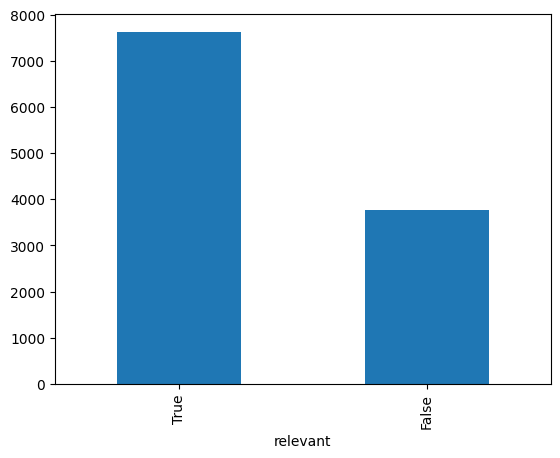

In [16]:
df['relevant'].value_counts().plot(kind='bar')

<Axes: xlabel='humanitarian_label'>

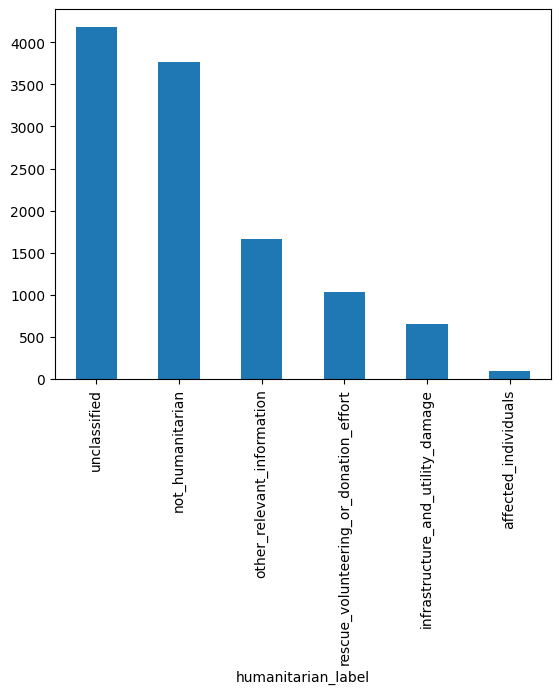

In [17]:
df['humanitarian_label'].value_counts().plot(kind='bar')

<Axes: xlabel='event_type'>

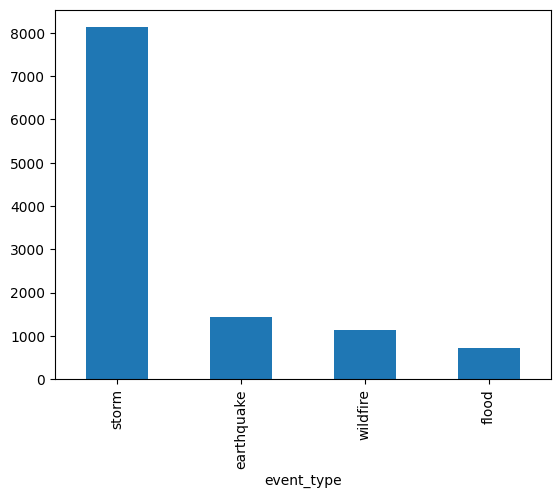

In [18]:
df['event_type'].value_counts().plot(kind='bar')